# **FICO® Xpress MoselPy - Chapter C: Production Planning**

***production_planning.ipynb*** - Production planning examples from the Xpress Applications Book - bicycle, glass, toy lorry, electronic components, fiberglass, and machine assignment, solved with MoselPy.

&copy; Copyright 2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/xpress-community#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q moselpy mosellibs xpresslibs matplotlib pandas

Run the cell below to import the necessary libraries and set `MODELS` and `DATA`, the path variables pointing to the Mosel model files and data files used in this notebook.

In [ ]:
# On Linux, preload the Xpress solver library so the Mosel optimizer module
# (mmxprs) can resolve it at runtime.
import sys, os, glob, ctypes, xpresslibs
if sys.platform == "linux":
    for _lib in glob.glob(os.path.join(xpresslibs.solver_libs_dir, "libxprs.so*")):
        ctypes.CDLL(_lib, mode=ctypes.RTLD_GLOBAL)

import moselpy as mp
from moselpy import ExecStatus
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

MODELS = "models/production_planning"
DATA   = "data/production_planning"

print(f"MoselPy {mp.version}  |  Mosel {mp.mosel_version}  |  Xpress {mp.xpress_version}")
mp.config.set_default_stream(mp.StreamType.OUTPUT, "null:")

MoselPy 6.12.0  |  Mosel 6012000  |  Xpress 10000000


## Production planning

This notebook covers six LP and MIP production planning examples from Chapter C of the Xpress Applications Book, solved via [MoselPy](https://pypi.org/project/moselpy/). Examples range from simple single-product capacity planning, through multi-product glass production and string-indexed toy assembly, to electronic components sensitivity analysis, fiberglass transshipment, and machine assignment.

> **Mosel source files:** [`models/production_planning/`](models/production_planning/) &nbsp;|&nbsp; **Data files:** [`data/production_planning/`](data/production_planning/)

> **Requirements:** `pip install moselpy mosellibs xpresslibs` - `mosellibs` provides the Mosel runtime and `xpresslibs` the Xpress solver libraries. No local Xpress installation is needed to run these notebooks, as long as the packages with libraries have been installed.

> A local FICO&reg; Xpress installation is recommended if you want access to the full set of examples, user guides and documentation, solver libraries, and Xpress Workbench. Obtain one via the [FICO&reg; Xpress community license](https://www.fico.com/en/fico-xpress-community-license) page. If a local installation is present, set `XPRESSDIR` before starting Jupyter to use it instead of the `mosellibs` and `xpresslibs` packages.

> **MoselPy documentation:** [MoselPy User Guide and Reference Manual](https://www.fico.com/fico-xpress-optimization/docs/latest/mosel/MoselPy/dhtml)

> **Mosel examples on the web:** [examples.xpress.fico.com](https://examples.xpress.fico.com/example.pl?id=mosel_app_3)

### MoselPy features demonstrated in this chapter

- **Parametric capacity scan**: C-1 loads the bicycle model once and runs with varying `CAP` values via `exec_params`, collecting total costs into a `pd.Series`.
- **Sensitivity analysis with `pd.DataFrame` pivot**: C-4 varies `CADD` and `CRED` in a nested loop and collects total costs into a 2D heatmap.
- **Binary I/O**: C-5 uses `mp.write_binary()` to write data to a `.bin` file and reads it via `DATASOURCE="bin:..."`.
- **Infeasibility detection**: C-6 demonstrates `model.prob_status.is_solution_available` by tightening machine capacities below feasible limits.

## C-1 Bicycle production (LP)

*Applications Book Chapter C, Example 1*

> **Mosel model:** [`c1bike_p.mos`](models/production_planning/c1bike_p.mos)

A sales forecast gives predicted bicycle demand for each of 12 months. Normal production capacity is `CAP` bikes/month; overtime adds up to 50% more at higher cost. Excess bikes can be stored (cost `CSTOCK` per bike). Find the production plan (normal, overtime, stored) that minimizes total annual cost.

**Sets:** $\text{TIMES} = 1..12$

**Decision variables:** $\mathit{pnorm}_t \geq 0$ (normal production in month $t$); $\mathit{pover}_t \geq 0$ (overtime production); $\mathit{store}_t \geq 0$ (stock at end of month $t$).

$$
\begin{align*}
\text{minimize}   \quad & \sum_{t \in \text{TIMES}} (\text{CNORM} \cdot \mathit{pnorm}_t + \text{COVER} \cdot \mathit{pover}_t + \text{CSTOCK} \cdot \mathit{store}_t) \\
\text{subject to} \quad & \mathit{pnorm}_t + \mathit{pover}_t + \mathit{store}_{t-1} = \text{DEM}_t + \mathit{store}_t \quad \forall\, t \quad (\mathit{store}_0 = \text{ISTOCK}) \\
                          & \mathit{pnorm}_t \leq \text{CAP} \quad \forall\, t \\
                          & \mathit{pover}_t \leq 0.5 \cdot \text{CAP} \quad \forall\, t
\end{align*}
$$

In [ ]:
MONTHS = {i+1: m for i, m in enumerate(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])}
DEM_BIKE = {i+1: v for i, v in enumerate([30000,15000,15000,25000,33000,40000,45000,45000,26000,14000,25000,30000])}
CNORM    = 32
COVER    = 40
CSTOCK_B = 5
CAP_BASE = 30000
ISTOCK_B = 2000

Compile and load `c1bike_p.mos` once. Then run it with the default data (CAP = 30000) to get the base solution. The model returns `obj_val` and solution arrays `sol_pnorm`, `sol_pover`, `sol_store` (each a dict indexed 1..12).

In [ ]:
mp.compile_model(f"{MODELS}/c1bike_p.mos", f"{MODELS}/c1bike_p.bim")
model = mp.load_model(f"{MODELS}/c1bike_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"DEM": DEM_BIKE, "CNORM": CNORM, "COVER": COVER,
                "CSTOCK": CSTOCK_B, "CAP": CAP_BASE, "ISTOCK": ISTOCK_B, "MONTHS": MONTHS},
)
if model.prob_status.is_solution_available:
    obj_val    = output["obj_val"]
    sol_pnorm  = output["sol_pnorm"]   # dict: month -> normal production
    sol_pover  = output["sol_pover"]   # dict: month -> overtime production
    sol_store  = output["sol_store"]   # dict: month -> stock level

    dem_list = list(DEM_BIKE.values())
    print(f"Total cost (CAP=30000): {obj_val:,.0f}")
    print()
    print(f"{'Month':<5} {'Demand':>8} {'Normal':>8} {'Overtime':>9} {'Stock':>7}")
    for t in range(1, 13):
        print(f"  {MONTHS[t]:<4} {dem_list[t-1]:>8,} {sol_pnorm[t]:>8,.0f} {sol_pover[t]:>9,.0f} {sol_store[t]:>7,.0f}")
else:
    print(f"No solution found ({model.prob_status})")

Total cost (CAP=30000): 11,247,000



Month   Demand   Normal  Overtime   Stock
  Jan    30,000   28,000         0       0
  Feb    15,000   15,000         0       0
  Mar    15,000   15,000         0       0
  Apr    25,000   28,000         0   3,000
  May    33,000   30,000         0       0
  Jun    40,000   30,000    10,000       0
  Jul    45,000   30,000    15,000       0
  Aug    45,000   30,000    15,000       0
  Sep    26,000   26,000         0       0
  Oct    14,000   14,000         0       0
  Nov    25,000   25,000         0       0
  Dec    30,000   30,000         0       0


The compiled model is already loaded - no recompile needed. Run a parametric capacity loop: vary `CAP` from 22000 to 36000 in steps of 2000, passing each value as an `exec_params` override. The remaining data is passed via `input_data` as before. Collect the total cost at each capacity into a `pd.Series`.

In [ ]:
cap_values = range(22000, 38000, 2000)
costs = {}
for cap in cap_values:
    out = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
        input_data={"DEM": DEM_BIKE, "CNORM": CNORM, "COVER": COVER,
                    "CSTOCK": CSTOCK_B, "CAP": cap, "ISTOCK": ISTOCK_B, "MONTHS": MONTHS},
    )
    if model.prob_status.is_solution_available:
        costs[cap] = out["obj_val"]
    else:
        costs[cap] = float("nan")

cost_series = pd.Series(costs, name="Total cost")
cost_series.index.name = "CAP"
print("Parametric capacity results:")
print(cost_series.apply(lambda v: f"{v:,.0f}").to_string())

Parametric capacity results:
CAP
22000    12,223,000
24000    11,870,000
26000    11,593,000
28000    11,386,000
30000    11,247,000
32000    11,189,000
34000    11,133,000
36000    11,079,000


Two-panel chart: (left) stacked bar chart of normal production, overtime, and stock by month with the demand line overlaid; (right) total cost vs capacity from the parametric run above.

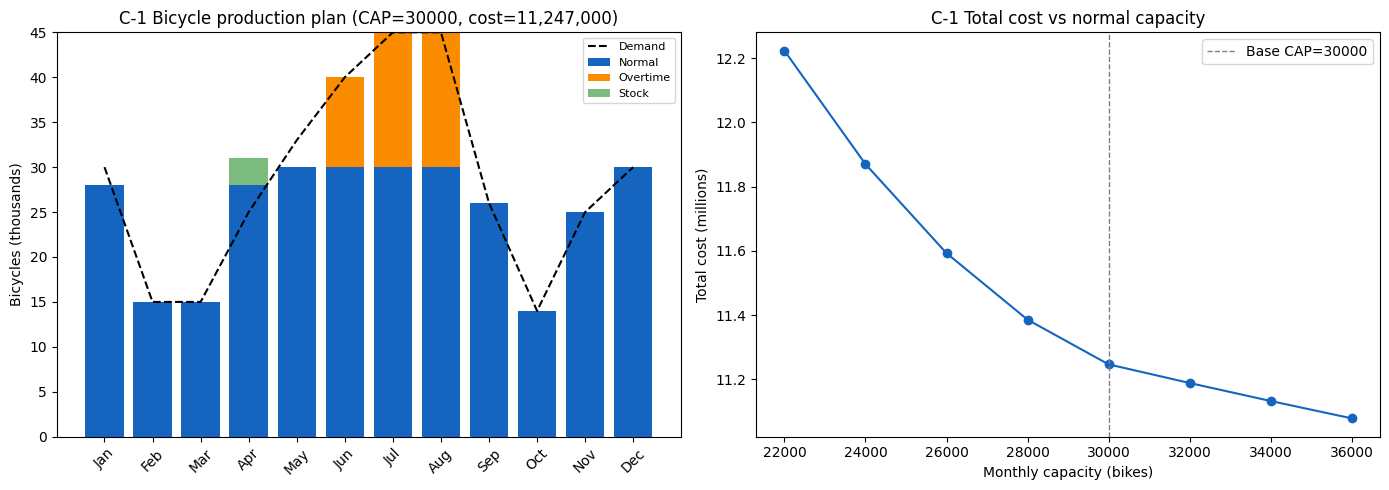

In [ ]:
months_list = list(MONTHS.values())   # ["Jan", ..., "Dec"]
dem_list    = list(DEM_BIKE.values()) # [30000, ..., 30000]
months_idx  = range(1, 13)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: production breakdown
norm_vals  = [sol_pnorm[t]/1000 for t in months_idx]
over_vals  = [sol_pover[t]/1000 for t in months_idx]
store_vals = [sol_store[t]/1000 for t in months_idx]
dem_vals   = [d/1000 for d in dem_list]

x = np.arange(12)
ax1.bar(x, norm_vals,  label="Normal",   color="#1565C0")
ax1.bar(x, over_vals,  bottom=norm_vals, label="Overtime", color="#FB8C00")
ax1.bar(x, store_vals, bottom=[n+o for n,o in zip(norm_vals, over_vals)],
        label="Stock", color="#43A047", alpha=0.7)
ax1.plot(x, dem_vals, "k--", linewidth=1.5, label="Demand")
ax1.set_xticks(x); ax1.set_xticklabels(months_list, rotation=45)
ax1.set_ylabel("Bicycles (thousands)")
ax1.set_title(f"C-1 Bicycle production plan (CAP=30000, cost={obj_val:,.0f})")
ax1.legend(loc="upper right", fontsize=8)

# Right: cost vs capacity
cap_list  = list(cost_series.index)
cost_list = list(cost_series.values)
ax2.plot(cap_list, [c/1e6 for c in cost_list], "o-", color="#1565C0")
ax2.axvline(30000, color="gray", linestyle="--", linewidth=1, label="Base CAP=30000")
ax2.set_xlabel("Monthly capacity (bikes)")
ax2.set_ylabel("Total cost (millions)")
ax2.set_title("C-1 Total cost vs normal capacity")
ax2.legend()

plt.tight_layout(); plt.show()

## C-2 Glass production (LP)

*Applications Book Chapter C, Example 2*

> **Mosel model:** [`c2glass_p.mos`](models/production_planning/c2glass_p.mos)

A French company produces 6 types of drinking glasses over a 12-week planning horizon. Each glass type has its own production cost, storage cost, worker time, machine time, and space requirement. Weekly worker hours, machine hours, and storage space are all limited. Determine how much of each type to produce each week to minimize total cost while meeting all demands and ending with minimum final stocks.

**Sets:** $\text{PRODS} = 1..6$, $\text{WEEKS} = 1..12$

**Decision variables:** $\mathit{produce}_{p,t} \geq 0$ (units of product $p$ produced in week $t$); $\mathit{store}_{p,t} \geq 0$ (stock at end of week $t$).

$$
\begin{align*}
\text{minimize}   \quad & \sum_{p,t} (\text{CPROD}_p \cdot \mathit{produce}_{p,t} + \text{CSTOCK}_p \cdot \mathit{store}_{p,t}) \\
\text{subject to} \quad & \mathit{store}_{p,t} = \mathit{store}_{p,t-1} + \mathit{produce}_{p,t} - \text{DEM}_{p,t} \quad \forall\, p,t \quad (\mathit{store}_{p,0} = \text{ISTOCK}_p) \\
                          & \mathit{store}_{p,12} \geq \text{FSTOCK}_p \quad \forall\, p \\
                          & \sum_p \text{TIMEW}_p \cdot \mathit{produce}_{p,t} \leq \text{CAPW} \quad \forall\, t \\
                          & \sum_p \text{TIMEM}_p \cdot \mathit{produce}_{p,t} \leq \text{CAPM} \quad \forall\, t \\
                          & \sum_p \text{SPACE}_p \cdot \mathit{store}_{p,t} \leq \text{CAPS} \quad \forall\, t
\end{align*}
$$

In [ ]:
PRODS_G = [1,2,3,4,5,6]
WEEKS_G  = list(range(1, 13))
DEM_G_DATA = [
    [20,22,18,35,17,19,23,20,29,30,28,32],
    [17,19,23,20,11,10,12,34,21,23,30,12],
    [18,35,17,10, 9,21,23,15,10, 0,13,17],
    [31,45,24,38,41,20,19,37,28,12,30,37],
    [23,20,23,15,10,22,18,30,28, 7,15,10],
    [22,18,20,19,18,35, 0,28,12,30,21,23],
]
DEM_G    = pd.DataFrame(DEM_G_DATA, index=PRODS_G, columns=WEEKS_G)
CPROD_G  = {i+1: v for i, v in enumerate([100, 80, 110, 90, 200, 140])}
CSTOCK_G = {i+1: v for i, v in enumerate([25, 28, 25, 27, 10, 20])}
FSTOCK_G = {i+1: v for i, v in enumerate([10, 10, 10, 10, 10, 10])}
ISTOCK_G = {i+1: v for i, v in enumerate([50, 20, 0, 15, 0, 10])}
CAPW_G, CAPM_G, CAPS_G = 390, 850, 1000
TIMEW_G  = {i+1: v for i, v in enumerate([3, 3, 3, 2, 4, 4])}
TIMEM_G  = {i+1: v for i, v in enumerate([2, 1, 4, 8, 11, 9])}
SPACE_G  = {i+1: v for i, v in enumerate([4, 5, 5, 6, 4, 9])}

Heatmap of weekly demand per glass type. Each row is a product, each column is a week. High-demand cells stand out immediately and help build intuition before seeing the optimized production plan.

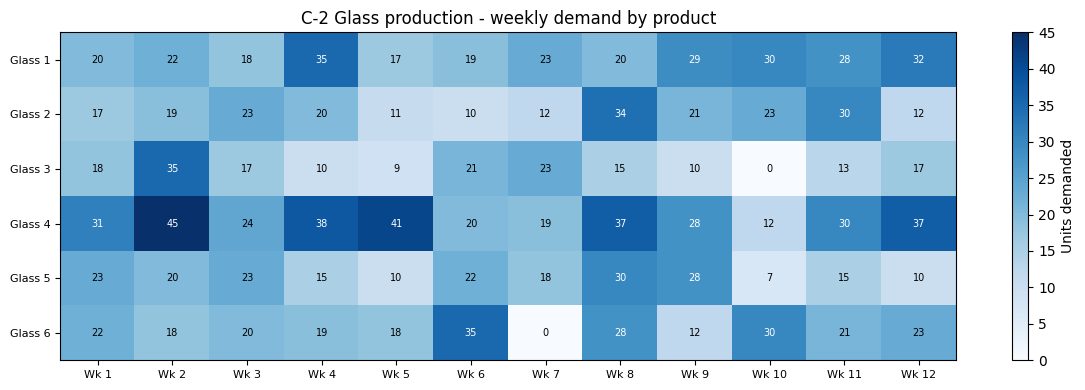

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(DEM_G.values, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="Units demanded")
ax.set_xticks(range(12)); ax.set_xticklabels([f"Wk {w}" for w in range(1, 13)], fontsize=8)
ax.set_yticks(range(6));  ax.set_yticklabels([f"Glass {p}" for p in range(1, 7)], fontsize=8)
for p in range(6):
    for w in range(12):
        ax.text(w, p, str(DEM_G.iloc[p, w]), ha="center", va="center", fontsize=7,
                color="white" if DEM_G.iloc[p, w] > 25 else "black")
ax.set_title("C-2 Glass production - weekly demand by product")
plt.tight_layout(); plt.show()

Compile and run `c2glass_p.mos`. The model returns `sol_produce` and `sol_store` as dicts with tuple keys `(product, week)`. Reshape these into DataFrames (products as rows, weeks as columns) for inspection and visualization.

In [ ]:
mp.compile_model(f"{MODELS}/c2glass_p.mos", f"{MODELS}/c2glass_p.bim")
with mp.load_model(f"{MODELS}/c2glass_p.bim") as model:
    output = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
        input_data={"DEM": DEM_G, "CPROD": CPROD_G, "CSTOCK": CSTOCK_G, "FSTOCK": FSTOCK_G,
                    "ISTOCK": ISTOCK_G, "CAPW": CAPW_G, "CAPM": CAPM_G, "CAPS": CAPS_G,
                    "TIMEW": TIMEW_G, "TIMEM": TIMEM_G, "SPACE": SPACE_G},
    )
    if model.prob_status.is_solution_available:
        obj_val     = output["obj_val"]
        sol_produce = output["sol_produce"]   # dict: (product, week) -> real
        sol_store   = output["sol_store"]     # dict: (product, week) -> real

        NP, NW = 6, 12
        produce_df = pd.DataFrame(
            {w: [sol_produce[(p, w)] for p in range(1, NP+1)] for w in range(1, NW+1)},
            index=[f"Glass {p}" for p in range(1, NP+1)]
        )
        produce_df.columns.name = "Week"

        print(f"Total cost: {obj_val:,.0f}")
        print()
        print("Production plan (units per week):")
        print(produce_df.round(0).astype(int).to_string())
    else:
        print(f"No solution found ({model.prob_status})")

Total cost: 185,899

Production plan (units per week):
Week     1   2   3   4   5   6   7   8   9   10  11  12
Glass 1   9   5   1  30  27   9  23  20  29  30  28  42
Glass 2   0  16  23  20  11  10  12  34  21  23  30  22
Glass 3  18  35  17  10   9  21  23  15  10   0  13  27
Glass 4  16  45  24  38  41  20  19  37  28  12  30  47
Glass 5  48  15  35  14  23  23  44   0  26   3   0   0
Glass 6  12  18  20  19  18  35   1  27  12  49  29   6


Two-panel dashboard: (top) stacked bar chart showing weekly production by glass type; (bottom) capacity utilization for workers, machines, and storage across weeks.

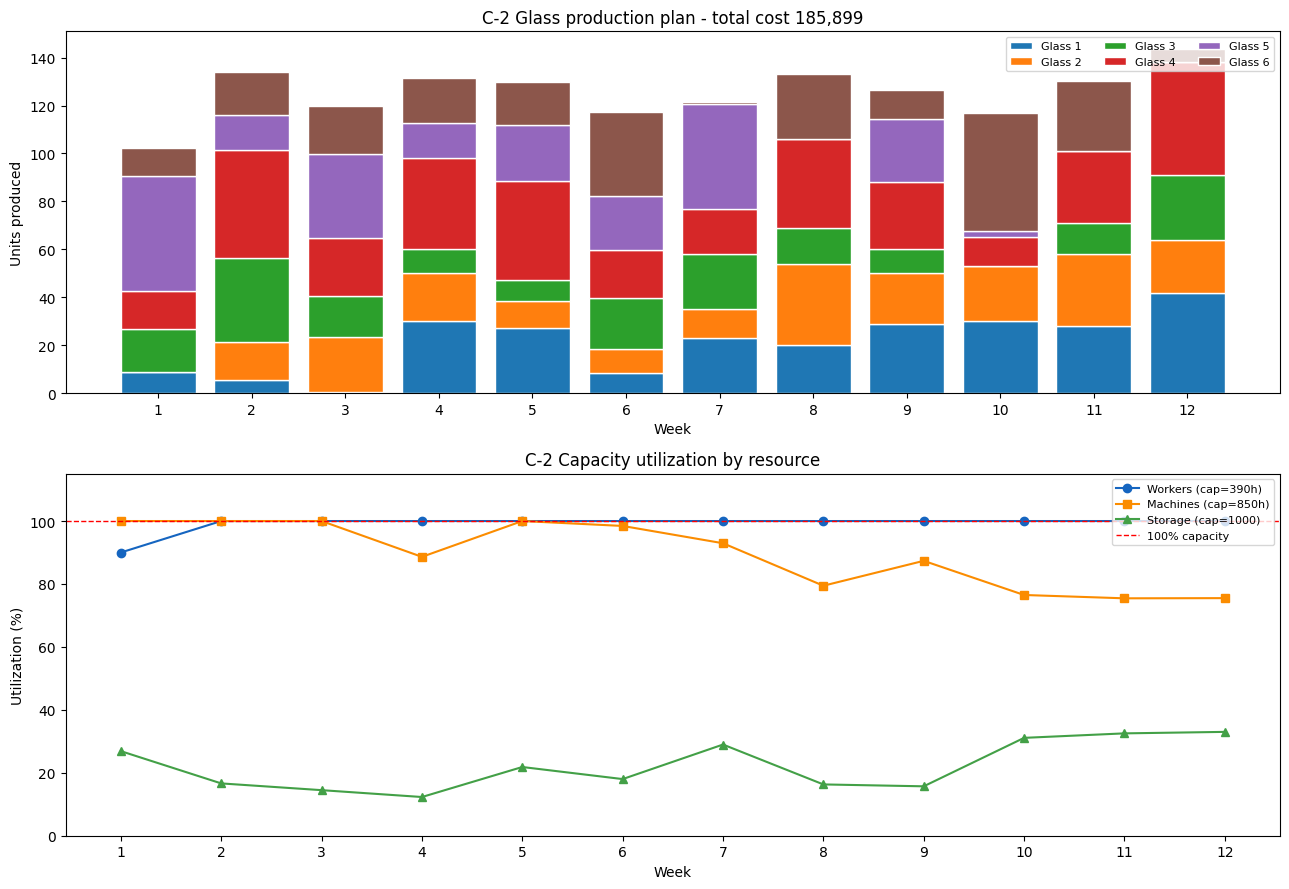

In [ ]:
NP, NW = 6, 12
prod_colors = plt.cm.tab10.colors

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9))

# Top: stacked bar - weekly production by glass type
weeks = list(range(1, NW+1))
bottoms = np.zeros(NW)
for p in range(1, NP+1):
    vals = np.array([sol_produce[(p, w)] for w in weeks])
    ax1.bar(weeks, vals, bottom=bottoms, color=prod_colors[(p-1) % 10],
            label=f"Glass {p}", edgecolor="white")
    bottoms += vals
ax1.set_xticks(weeks)
ax1.set_xlabel("Week")
ax1.set_ylabel("Units produced")
ax1.set_title(f"C-2 Glass production plan - total cost {obj_val:,.0f}")
ax1.legend(loc="upper right", ncol=3, fontsize=8)

# Bottom: capacity utilization
worker_util  = [sum(TIMEW_G[p]*sol_produce[(p,w)] for p in range(1,NP+1)) for w in weeks]
machine_util = [sum(TIMEM_G[p]*sol_produce[(p,w)] for p in range(1,NP+1)) for w in weeks]
storage_util = [sum(SPACE_G[p]*sol_store[(p,w)]   for p in range(1,NP+1)) for w in weeks]

ax2.plot(weeks, [u/CAPW_G*100 for u in worker_util],  "o-", color="#1565C0", label=f"Workers (cap={CAPW_G}h)")
ax2.plot(weeks, [u/CAPM_G*100 for u in machine_util], "s-", color="#FB8C00", label=f"Machines (cap={CAPM_G}h)")
ax2.plot(weeks, [u/CAPS_G*100 for u in storage_util], "^-", color="#43A047", label=f"Storage (cap={CAPS_G})")
ax2.axhline(100, color="red", linestyle="--", linewidth=1, label="100% capacity")
ax2.set_xticks(weeks)
ax2.set_xlabel("Week")
ax2.set_ylabel("Utilization (%)")
ax2.set_title("C-2 Capacity utilization by resource")
ax2.legend(loc="upper right", fontsize=8)
ax2.set_ylim(0, 115)

plt.tight_layout(); plt.show()

## C-3 Toy lorry production (MIP)

*Applications Book Chapter C, Example 3*

> **Mosel model:** [`c3toy_p.mos`](models/production_planning/c3toy_p.mos)

A company produces two types of toy lorry (blue and red), each requiring 13 components. Some components can be assembled in-house; others must be bought. Given equal demand for both lorry types, decide how many of each item to produce or buy to minimize total cost.

The model uses **string-indexed sets** (`ASMBL`, `PREPROD`, `FINAL`, `ITEMS`) inferred from the data. All input arrays (`DEM`, `CBUY`, `REQ`, `CPROD`, `CAP`) are passed from Python via `input_data`. When results are returned to Python, all dictionaries use **string keys** matching the Mosel item names.

**Sets:** $\text{ITEMS}$, $\text{FINAL} \subset \text{ITEMS}$, $\text{ASMBL} \subset \text{ITEMS}$, $\text{PREPROD} \subset \text{ITEMS}$

**Decision variables:** $\mathit{produce}_p \in \mathbb{Z}_{\geq 0}$ for $p \in \text{ASMBL}$; $\mathit{buy}_p \in \mathbb{Z}_{\geq 0}$ for $p \in \text{PREPROD}$.

$$
\begin{align*}
\text{minimize}   \quad & \sum_{p \in \text{PREPROD}} \text{CBUY}_p \cdot \mathit{buy}_p + \sum_{p \in \text{ASMBL}} \text{CPROD}_p \cdot \mathit{produce}_p \\
\text{subject to} \quad & \mathit{produce}_p \geq \text{DEM}_p \quad \forall\, p \in \text{FINAL} \\
                          & \mathit{buy}_p + \mathit{produce}_p \cdot [p \in \text{ASMBL}] \geq \sum_{q \in \text{ASMBL}} \text{REQ}_{q,p} \cdot \mathit{produce}_q \quad \forall\, p \in \text{PREPROD} \\
                          & \mathit{produce}_p \leq \text{CAP}_p \quad \forall\, p \in \text{ASMBL}
\end{align*}
$$

In [ ]:
REQ_T = {
    ("axle","wheel"):2, ("axle","steel bar"):1,
    ("assembled chassis","bumper"):2, ("assembled chassis","axle"):2, ("assembled chassis","chassis"):1,
    ("assembled cabin","cabin"):1, ("assembled cabin","door window"):2, ("assembled cabin","windscreen"):1,
    ("blue lorry","assembled chassis"):1, ("blue lorry","container"):1, ("blue lorry","assembled cabin"):1,
    ("blue lorry","blue motor"):1, ("blue lorry","headlight"):2,
    ("red lorry","assembled chassis"):1, ("red lorry","tank"):1, ("red lorry","assembled cabin"):1,
    ("red lorry","red motor"):1, ("red lorry","headlight"):2,
}
CBUY_T = {
    "wheel":0.30, "steel bar":1, "bumper":0.2, "axle":12.75, "chassis":0.8,
    "cabin":2.75, "door window":0.1, "windscreen":0.29, "assembled chassis":30,
    "container":2.60, "tank":3, "assembled cabin":3, "blue motor":1.65,
    "red motor":1.65, "headlight":0.15,
}
CPROD_T = {"axle":6.80, "assembled chassis":3.55, "assembled cabin":3.20, "blue lorry":2.20, "red lorry":2.60}
CAP_T   = {"axle":600,  "assembled chassis":4000,  "assembled cabin":3000,  "blue lorry":4000,  "red lorry":5000}
DEM_T   = {"blue lorry":3000, "red lorry":3000}

Compile and run `c3toy_p.mos`. Because sets are string-indexed, `sol_produce` and `sol_buy` come back as Python dicts with string keys (e.g. `sol_produce["blue lorry"]`, `sol_buy["wheel"]`). No integer indices needed.

In [ ]:
mp.compile_model(f"{MODELS}/c3toy_p.mos", f"{MODELS}/c3toy_p.bim")
with mp.load_model(f"{MODELS}/c3toy_p.bim") as model:
    output = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
        input_data={"DEM": DEM_T, "CBUY": CBUY_T, "REQ": REQ_T, "CPROD": CPROD_T, "CAP": CAP_T},
    )
    if model.prob_status.is_solution_available:
        obj_val     = output["obj_val"]
        sol_produce = output["sol_produce"]   # dict: item_name -> real (ASMBL only)
        sol_buy     = output["sol_buy"]       # dict: item_name -> real (PREPROD only)

        print(f"Total cost: {obj_val:,.2f}")
        print()
        print("Produce (assembled items):")
        for item, qty in sorted(sol_produce.items()):
            print(f"  {item:<25}: {qty:>6.0f}")
        print()
        print("Buy (purchased items):")
        for item, qty in sorted(sol_buy.items()):
            if qty > 0.5:
                print(f"  {item:<25}: {qty:>6.0f}")
    else:
        print(f"No solution found ({model.prob_status})")

Total cost: 238,365.00

Produce (assembled items):
  assembled cabin          :     -0
  assembled chassis        :    300
  axle                     :    600
  blue lorry               :   3000
  red lorry                :   3000

Buy (purchased items):
  assembled cabin          :   6000
  assembled chassis        :   5700
  blue motor               :   3000
  bumper                   :    600
  chassis                  :    300
  container                :   3000
  headlight                :  12000
  red motor                :   3000
  steel bar                :    600
  tank                     :   3000
  wheel                    :   1200


Bar chart showing production and purchase quantities by item, colored by type (assembled vs bought). Items with zero quantity are omitted.

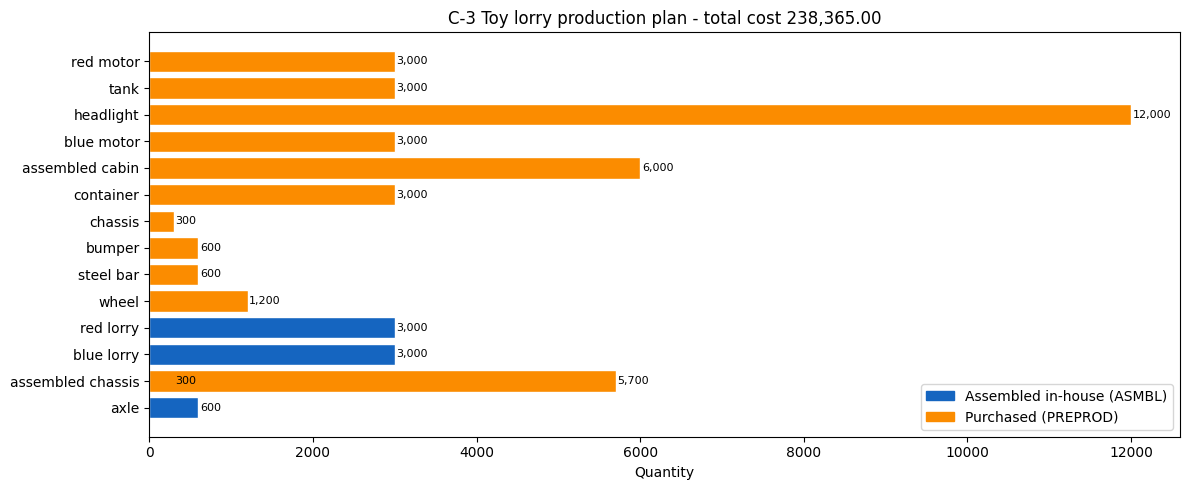

In [ ]:
assembled_items = {k: v for k, v in sol_produce.items() if v > 0.5}
bought_items    = {k: v for k, v in sol_buy.items()     if v > 0.5}

all_items = list(assembled_items.keys()) + list(bought_items.keys())
all_qtys  = list(assembled_items.values()) + list(bought_items.values())
colors    = ["#1565C0"] * len(assembled_items) + ["#FB8C00"] * len(bought_items)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(all_items, all_qtys, color=colors, edgecolor="white")
for bar, qty in zip(bars, all_qtys):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"{qty:,.0f}", va="center", fontsize=8)

blue_patch  = mpatches.Patch(color="#1565C0", label="Assembled in-house (ASMBL)")
orange_patch = mpatches.Patch(color="#FB8C00", label="Purchased (PREPROD)")
ax.legend(handles=[blue_patch, orange_patch], loc="lower right")
ax.set_xlabel("Quantity")
ax.set_title(f"C-3 Toy lorry production plan - total cost {obj_val:,.2f}")
plt.tight_layout(); plt.show()

## C-4 Electronic components (LP)

*Applications Book Chapter C, Example 4*

> **Mosel model:** [`c4compo_p.mos`](models/production_planning/c4compo_p.mos)

A company produces 4 electronic components (X43-M1, X43-M2, Y54-N1, Y54-N2) over 6 months. The objective includes production costs, storage costs, and a penalty for changing the total production level between months (`CADD` for increases, `CRED` for decreases). Meet monthly demands while guaranteeing minimum final stocks.

`c4compo_p.mos` exposes `CADD` and `CRED` as `parameters` so they can be overridden via `exec_params` from Python. This enables sensitivity analysis without recompiling.

**Sets:** $\text{PRODS} = 1..4$, $\text{MONTHS} = 1..6$

**Decision variables:** $\mathit{produce}_{p,t} \geq 0$; $\mathit{store}_{p,t} \geq 0$; $\mathit{add}_t \geq 0$; $\mathit{reduce}_t \geq 0$.

$$
\begin{align*}
\text{minimize}   \quad & \sum_{p,t} (\text{CPROD}_p \cdot \mathit{produce}_{p,t} + \text{CSTOCK}_p \cdot \mathit{store}_{p,t}) + \sum_{t=2}^{6} (\text{CADD} \cdot \mathit{add}_t + \text{CRED} \cdot \mathit{reduce}_t) \\
\text{subject to} \quad & \mathit{store}_{p,t} = \mathit{store}_{p,t-1} + \mathit{produce}_{p,t} - \text{DEM}_{p,t} \quad \forall\, p,t \\
                          & \sum_p (\mathit{produce}_{p,t} - \mathit{produce}_{p,t-1}) = \mathit{add}_t - \mathit{reduce}_t \quad \forall\, t \geq 2 \\
                          & \mathit{store}_{p,6} \geq \text{FSTOCK}_p \quad \forall\, p
\end{align*}
$$

In [ ]:
CPROD_C4  = {1:20, 2:25, 3:10, 4:15}
CSTOCK_C4 = {1:0.4, 2:0.5, 3:0.3, 4:0.3}
DEM_C4    = {(1,1):1500,(1,2):3000,(1,3):2000,(1,4):4000,(1,5):2000,(1,6):2500,
             (2,1):1300,(2,2): 800,(2,3): 800,(2,4):1000,(2,5):1100,(2,6): 900,
             (3,1):2200,(3,2):1500,(3,3):2900,(3,4):1800,(3,5):1200,(3,6):2100,
             (4,1):1400,(4,2):1600,(4,3):1500,(4,4):1000,(4,5):1100,(4,6):1200}
ISTOCK_C4 = {1:10, 2:0, 3:50, 4:0}
FSTOCK_C4 = {1:50, 2:10, 3:30, 4:10}
PNAME_C4  = {1:"X43-M1", 2:"X43-M2", 3:"Y54-N1", 4:"Y54-N2"}

Compile and load `c4compo_p.mos` once. Run the base case (CADD=1.0, CRED=0.5 - the model parameter defaults) and display results.

In [ ]:
mp.compile_model(f"{MODELS}/c4compo_p.mos", f"{MODELS}/c4compo_p.bim")
model_c4 = mp.load_model(f"{MODELS}/c4compo_p.bim")
model_c4.set_default_stream(mp.StreamType.OUTPUT, "null:")

output_c4 = model_c4.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"DEM": DEM_C4, "CPROD": CPROD_C4, "CSTOCK": CSTOCK_C4,
                "ISTOCK": ISTOCK_C4, "FSTOCK": FSTOCK_C4, "PNAME": PNAME_C4},
)
if model_c4.prob_status.is_solution_available:
    obj_val_c4  = output_c4["obj_val"]
    sol_produce = output_c4["sol_produce"]   # dict: (product, month) -> real
    sol_store   = output_c4["sol_store"]     # dict: (product, month) -> real

    pname_list = list(PNAME_C4.values())
    NP, NM = 4, 6

    produce_df = pd.DataFrame(
        {t: [sol_produce[(p, t)] for p in range(1, NP+1)] for t in range(1, NM+1)},
        index=pname_list
    )
    produce_df.columns = [f"M{t}" for t in range(1, NM+1)]

    print(f"Total cost (CADD=1.0, CRED=0.5): {obj_val_c4:,.2f}")
    print()
    print("Production plan:")
    print(produce_df.round(0).astype(int).to_string())
else:
    print(f"No solution found ({model_c4.prob_status})")

Total cost (CADD=1.0, CRED=0.5): 683,929.00

Production plan:
          M1    M2    M3    M4    M5    M6
X43-M1  1490  3000  2000  4000  2000  2550
X43-M2  1300   800   800  1000  1100   910
Y54-N1  2870   780  3640  1060  1200  2130
Y54-N2  1400  2480   620  1000  1800   510


With the model already compiled and loaded, run a sensitivity analysis over `CADD` in [0.5, 1.0, 1.5, 2.0] and `CRED` in [0.25, 0.5, 0.75, 1.0]. For each combination, override both parameters via `exec_params` while passing the data via `input_data`. Collect the total cost into a `pd.DataFrame` pivot for visualization.

In [ ]:
cadd_values = [0.5, 1.0, 1.5, 2.0]
cred_values = [0.25, 0.5, 0.75, 1.0]

results = {}
for cadd in cadd_values:
    for cred in cred_values:
        out = model_c4.run(
            exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "CADD": cadd, "CRED": cred},
            input_data={"DEM": DEM_C4, "CPROD": CPROD_C4, "CSTOCK": CSTOCK_C4,
                        "ISTOCK": ISTOCK_C4, "FSTOCK": FSTOCK_C4, "PNAME": PNAME_C4},
        )
        results[(cadd, cred)] = out["obj_val"] if model_c4.prob_status.is_solution_available else float("nan")

sens_df = pd.DataFrame(
    [[results[(cadd, cred)] for cred in cred_values] for cadd in cadd_values],
    index=[f"CADD={v}" for v in cadd_values],
    columns=[f"CRED={v}" for v in cred_values],
)
print("Total cost sensitivity analysis (CADD x CRED):")
print(sens_df.round(2).to_string())

Total cost sensitivity analysis (CADD x CRED):
          CRED=0.25  CRED=0.5  CRED=0.75  CRED=1.0
CADD=0.5   683689.0  683929.0   684169.0  684409.0
CADD=1.0   683689.0  683929.0   684169.0  684409.0
CADD=1.5   683689.0  683929.0   684169.0  684409.0
CADD=2.0   683689.0  683929.0   684169.0  684409.0


Heatmap of total cost across the (CADD, CRED) grid. Higher change-of-production costs lead to a smoother (more stable) production plan at higher total cost.

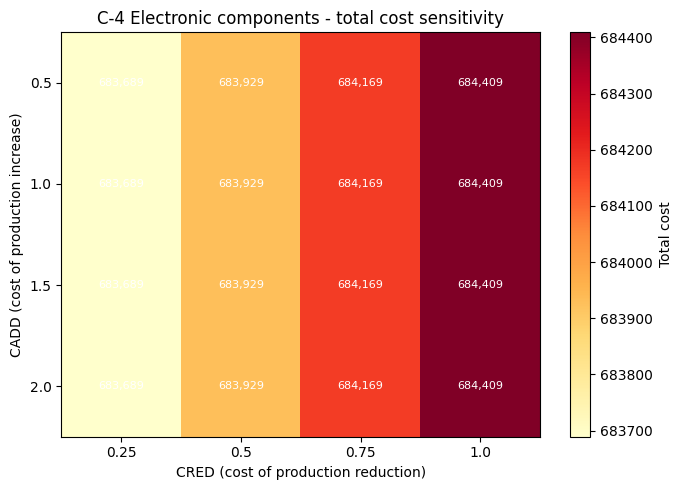

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(sens_df.values, cmap="YlOrRd", aspect="auto")
fig.colorbar(im, ax=ax, label="Total cost")

ax.set_xticks(range(len(cred_values)))
ax.set_xticklabels([f"{v}" for v in cred_values])
ax.set_yticks(range(len(cadd_values)))
ax.set_yticklabels([f"{v}" for v in cadd_values])
ax.set_xlabel("CRED (cost of production reduction)")
ax.set_ylabel("CADD (cost of production increase)")
ax.set_title("C-4 Electronic components - total cost sensitivity")

for i, cadd in enumerate(cadd_values):
    for j, cred in enumerate(cred_values):
        val = results[(cadd, cred)]
        ax.text(j, i, f"{val:,.0f}", ha="center", va="center", fontsize=8,
                color="black" if val < sens_df.values.max()*0.75 else "white")

plt.tight_layout(); plt.show()

## C-5 Fiberglass (LP)

*Applications Book Chapter C, Example 5*

> **Mosel model:** [`c5fiber_p.mos`](models/production_planning/c5fiber_p.mos)

Six weeks of fiberglass production and storage must be planned. The problem is modelled as a **transshipment network**: 12 nodes where odd-numbered nodes are production nodes (supply) and even-numbered nodes are demand nodes. Arcs represent production (odd-to-even, cost = production cost) and storage (even-to-even+2, cost = storage cost).

`c5fiber_p.mos` accepts `DATASOURCE` as a path to either a text `.dat` file or a Mosel binary `.bin` file. This section demonstrates `mp.write_binary()` to write data as a binary blob, then pass `DATASOURCE="bin:..."` to the model.

**Sets:** $\text{NODES} = 1..12$ (odd = production, even = demand)

**Decision variables:** $\mathit{flow}_{m,n} \geq 0$ for each arc $(m,n)$ in $\text{ARC}$ (dynamic - only created where arc exists).

$$
\begin{align*}
\text{minimize}   \quad & \sum_{(m,n) \in \text{ARC}} \text{ARC}_{m,n} \cdot \mathit{flow}_{m,n} \\
\text{subject to} \quad & \mathit{flow}_{n-2,n} + \mathit{flow}_{n-1,n} = \mathit{flow}_{n,n+2} + \text{WEIGHT}_n \quad \forall\, n \text{ even} \\
                          & \mathit{flow}_{n,n+1} \leq \text{WEIGHT}_n \quad \forall\, n \text{ odd}
\end{align*}
$$

First, define the arc and weight data as Python dicts. Write a Mosel binary file with `mp.write_binary()`, then compile and run the model with `DATASOURCE` pointing to the binary file via the `"bin:"` prefix. The model reads the data identically - the only difference from the text `.dat` is the file format.

In [ ]:
# Define data matching c5fiber_p.dat exactly
arc_data = {
    (1,  2): 5,    (3,  4): 8,    (5,  6): 6,
    (7,  8): 6,    (9, 10): 7,   (11, 12): 6,
    (2,  4): 0.2,  (4,  6): 0.3,  (6,  8): 0.2,
    (8, 10): 0.25, (10, 12): 0.3,
}
weight_data = {n: v for n, v in enumerate(
    [140, 100, 100, 120, 110, 100, 100, 90, 120, 120, 100, 110], start=1
)}

# Write as Mosel binary file
bin_path = f"{DATA}/c5fiber_p.bin"
mp.write_binary(bin_path, {"ARC": arc_data, "WEIGHT": weight_data})
print(f"Binary file written: {bin_path}")

# Compile and run using the binary file as DATASOURCE
mp.compile_model(f"{MODELS}/c5fiber_p.mos", f"{MODELS}/c5fiber_p.bim")
with mp.load_model(f"{MODELS}/c5fiber_p.bim") as model:
    output = model.run(exec_params={"DATASOURCE": f"bin:{bin_path}", "OUTFILE": "moselpy:"})
    if model.prob_status.is_solution_available:
        obj_val  = output["obj_val"]
        sol_flow = output["sol_flow"]   # dict: (m, n) -> real

        print()
        print(f"Total cost: {obj_val:,.2f}")
        print()
        print("Production and storage flows:")
        for week in range(1, 7):
            prod_node    = 2*week - 1
            demand_node  = 2*week
            production   = sol_flow.get((prod_node, demand_node), 0)
            storage_out  = sol_flow.get((demand_node, demand_node+2), 0) if demand_node < 12 else 0
            storage_in   = sol_flow.get((demand_node-2, demand_node), 0) if demand_node > 2 else 0
            print(f"  Week {week}: produced={production:.0f}  stored_in={storage_in:.0f}  stored_out={storage_out:.0f}")
    else:
        print(f"No solution found ({model.prob_status})")

Binary file written: data/production_planning/c5fiber_p.bin

Total cost: 3,988.00

Production and storage flows:
  Week 1: produced=140  stored_in=0  stored_out=40
  Week 2: produced=80  stored_in=40  stored_out=0
  Week 3: produced=110  stored_in=0  stored_out=10
  Week 4: produced=100  stored_in=10  stored_out=20
  Week 5: produced=110  stored_in=20  stored_out=10
  Week 6: produced=100  stored_in=10  stored_out=0


Network flow diagram: 12 nodes arranged in two rows (production nodes on top, demand nodes below). Arc width is proportional to flow; arc labels show cost and flow.

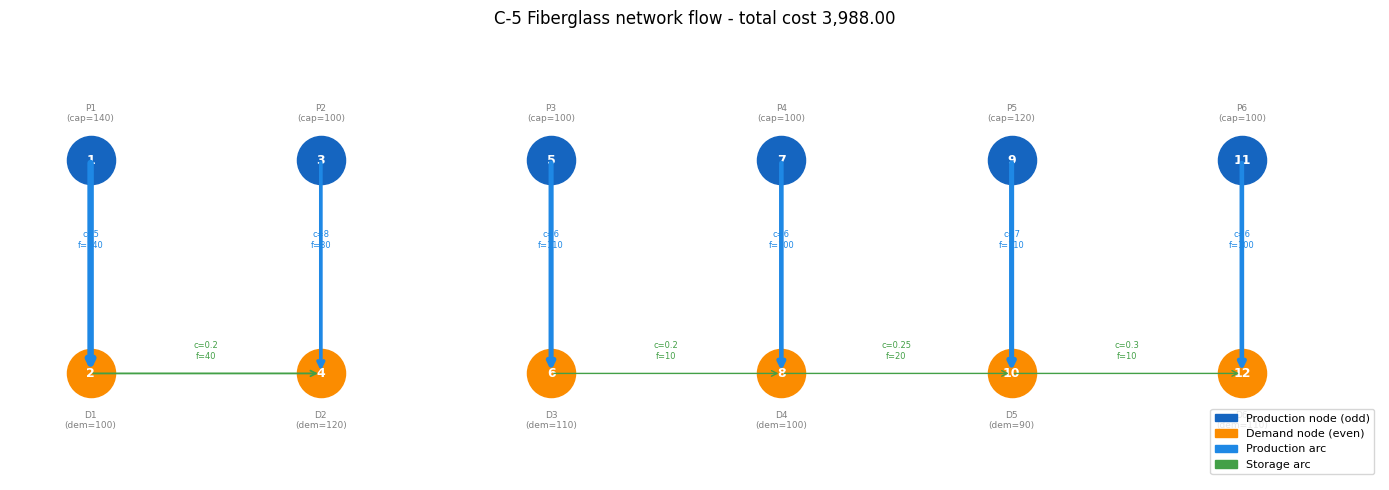

In [ ]:
WEEKS = 6
arc_costs = {
    (1,  2): 5,    (3,  4): 8,    (5,  6): 6,
    (7,  8): 6,    (9, 10): 7,   (11, 12): 6,
    (2,  4): 0.2,  (4,  6): 0.3,  (6,  8): 0.2,
    (8, 10): 0.25, (10, 12): 0.3,
}
demands  = [100, 120, 110, 100,  90, 110]
cap_prod = [140, 100, 100, 100, 120, 100]

fig, ax = plt.subplots(figsize=(14, 5))

node_x = {n: (n-1)//2 * 2.0 for n in range(1, 13)}
node_y = {n: 1.0 if n % 2 == 1 else 0.0 for n in range(1, 13)}

node_colors = {n: "#1565C0" if n % 2 == 1 else "#FB8C00" for n in range(1, 13)}
for n in range(1, 13):
    week = (n+1)//2
    label_top = f"P{week}\n(cap={cap_prod[week-1]})" if n % 2 == 1 else f"D{week}\n(dem={demands[week-1]})"
    ax.scatter(node_x[n], node_y[n], s=1200, color=node_colors[n], zorder=3)
    ax.text(node_x[n], node_y[n], str(n), ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")
    ax.text(node_x[n], node_y[n] + (0.22 if n%2==1 else -0.22), label_top,
            ha="center", va="center", fontsize=6.5, color="gray")

for (m, n), cost in arc_costs.items():
    flow = sol_flow.get((m, n), 0)
    if flow < 0.01:
        continue
    lw = max(1.0, flow / 30)
    color = "#1E88E5" if abs(node_y[m] - node_y[n]) > 0.1 else "#43A047"
    ax.annotate("", xy=(node_x[n], node_y[n]), xytext=(node_x[m], node_y[m]),
                arrowprops=dict(arrowstyle="->", color=color, lw=lw))
    mid_x = (node_x[m] + node_x[n]) / 2
    mid_y = (node_y[m] + node_y[n]) / 2 + (0.08 if node_y[m] != node_y[n] else 0.06)
    ax.text(mid_x, mid_y, f"c={cost}\nf={flow:.0f}", ha="center", va="bottom",
            fontsize=6, color=color)

ax.set_xlim(-0.7, 11.2); ax.set_ylim(-0.5, 1.6)
ax.axis("off")
prod_patch  = mpatches.Patch(color="#1565C0", label="Production node (odd)")
dem_patch   = mpatches.Patch(color="#FB8C00", label="Demand node (even)")
prod_arc    = mpatches.Patch(color="#1E88E5", label="Production arc")
store_arc   = mpatches.Patch(color="#43A047", label="Storage arc")
ax.legend(handles=[prod_patch, dem_patch, prod_arc, store_arc], loc="lower right", fontsize=8)
ax.set_title(f"C-5 Fiberglass network flow - total cost {obj_val:,.2f}")
plt.tight_layout(); plt.show()

## C-6 Machine assignment (MIP)

*Applications Book Chapter C, Example 6*

> **Mosel model:** [`c6assign_p.mos`](models/production_planning/c6assign_p.mos)

Ten production batches must each be assigned to exactly one of five machines. Each machine-batch pair has a known duration and cost. Each machine has a maximum total capacity (total duration it can handle). Find the assignment that minimizes total production cost.

Binary variable $\mathit{use}_{m,p} = 1$ if machine $m$ is assigned to batch $p$.

**Sets:** $\text{MACH} = 1..5$, $\text{PRODS} = 1..10$

**Decision variables:** $\mathit{use}_{m,p} \in \{0,1\}$

$$
\begin{align*}
\text{minimize}   \quad & \sum_{m,p} \text{COST}_{m,p} \cdot \mathit{use}_{m,p} \\
\text{subject to} \quad & \sum_m \mathit{use}_{m,p} = 1 \quad \forall\, p \quad \text{(one machine per batch)} \\
                          & \sum_p \text{DUR}_{m,p} \cdot \mathit{use}_{m,p} \leq \text{CAP}_m \quad \forall\, m \quad \text{(capacity limits)}
\end{align*}
$$

In [ ]:
NM_A, NB_A = 5, 10
CAP_A  = {1:18, 2:19, 3:25, 4:19, 5:20}
DUR_A  = {(1,1):8,(1,2):15,(1,3):14,(1,4):23,(1,5):8,(1,6):16,(1,7):8,(1,8):25,(1,9):9,(1,10):17,
          (2,1):15,(2,2):7,(2,3):23,(2,4):22,(2,5):11,(2,6):11,(2,7):12,(2,8):10,(2,9):17,(2,10):16,
          (3,1):21,(3,2):20,(3,3):6,(3,4):22,(3,5):24,(3,6):10,(3,7):24,(3,8):9,(3,9):21,(3,10):14,
          (4,1):20,(4,2):11,(4,3):8,(4,4):14,(4,5):9,(4,6):5,(4,7):6,(4,8):19,(4,9):19,(4,10):7,
          (5,1):8,(5,2):13,(5,3):13,(5,4):13,(5,5):10,(5,6):20,(5,7):25,(5,8):16,(5,9):16,(5,10):17}
COST_A = {(1,1):17,(1,2):21,(1,3):22,(1,4):18,(1,5):24,(1,6):15,(1,7):20,(1,8):18,(1,9):19,(1,10):18,
          (2,1):23,(2,2):16,(2,3):21,(2,4):16,(2,5):17,(2,6):16,(2,7):19,(2,8):25,(2,9):18,(2,10):21,
          (3,1):16,(3,2):20,(3,3):16,(3,4):25,(3,5):24,(3,6):16,(3,7):17,(3,8):19,(3,9):19,(3,10):18,
          (4,1):19,(4,2):19,(4,3):22,(4,4):22,(4,5):20,(4,6):16,(4,7):19,(4,8):17,(4,9):21,(4,10):19,
          (5,1):18,(5,2):19,(5,3):15,(5,4):15,(5,5):21,(5,6):25,(5,7):16,(5,8):16,(5,9):23,(5,10):15}

Compile and run `c6assign_p.mos` with the standard data. After the optimal solve, display the assignment and the duration utilization for each machine.

In [ ]:
mp.compile_model(f"{MODELS}/c6assign_p.mos", f"{MODELS}/c6assign_p.bim")
model_c6 = mp.load_model(f"{MODELS}/c6assign_p.bim")
model_c6.set_default_stream(mp.StreamType.OUTPUT, "null:")

output_c6 = model_c6.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"CAP": CAP_A, "DUR": DUR_A, "COST": COST_A},
)
if model_c6.prob_status.is_solution_available:
    obj_val_c6 = output_c6["obj_val"]
    sol_use    = output_c6["sol_use"]   # dict: (machine, batch) -> real

    cap_list = list(CAP_A.values())
    dur_rows = [[DUR_A[(m,p)] for p in range(1,NB_A+1)] for m in range(1,NM_A+1)]

    print(f"Total cost: {obj_val_c6:.0f}")
    print()
    print(f"{'Machine':<10} {'Capacity':>9} {'Used':>6} {'Batches'}")
    for m in range(1, NM_A+1):
        batches  = [p for p in range(1, NB_A+1) if sol_use[(m,p)] > 0.5]
        dur_used = sum(dur_rows[m-1][p-1] for p in batches)
        print(f"  Machine {m}   {cap_list[m-1]:>7}   {dur_used:>4}   {batches}")
else:
    print(f"No solution found ({model_c6.prob_status})")

Total cost: 173

Machine     Capacity   Used Batches
  Machine 1        18     17   [1, 9]
  Machine 2        19     18   [2, 5]
  Machine 3        25     15   [3, 8]
  Machine 4        19     18   [6, 7, 10]
  Machine 5        20     13   [4]


Demonstrating infeasibility detection via `model.prob_status`: reduce all machine capacities to 10 units. Batch 4 requires a minimum of 13 time units on any machine, so it cannot be scheduled - the problem has no feasible solution. When the MIP is infeasible, Xpress stops without finding a solution: `is_solution_available` returns `False` and `is_optimization_finished` returns `False`. The `prob_status` check catches this cleanly.

In [ ]:
CAP_TIGHT = {m: 10 for m in range(1, NM_A+1)}

out_tight = model_c6.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"CAP": CAP_TIGHT, "DUR": DUR_A, "COST": COST_A},
)
status = model_c6.prob_status

print(f"Status with tight capacities (CAP=[10,...,10]):")
print(f"  is_solution_available  : {status.is_solution_available}")
print(f"  is_solution_optimal    : {status.is_solution_optimal}")
print(f"  is_optimization_finished: {status.is_optimization_finished}")
print()
if not status.is_solution_available:
    print("No feasible assignment exists with CAP=[10,...,10].")
    print("Batch 4 requires at least 13 time units on any machine, exceeding the cap of 10.")
else:
    print(f"Optimal cost: {out_tight['obj_val']:.0f}")

Status with tight capacities (CAP=[10,...,10]):
  is_solution_available  : False
  is_solution_optimal    : False
  is_optimization_finished: False

No feasible assignment exists with CAP=[10,...,10].
Batch 4 requires at least 13 time units on any machine, exceeding the cap of 10.


Heatmap of the assignment matrix (machines x batches). Green cells = assigned (use=1); grey cells = not assigned (use=0). Machine capacity utilization shown on the right.

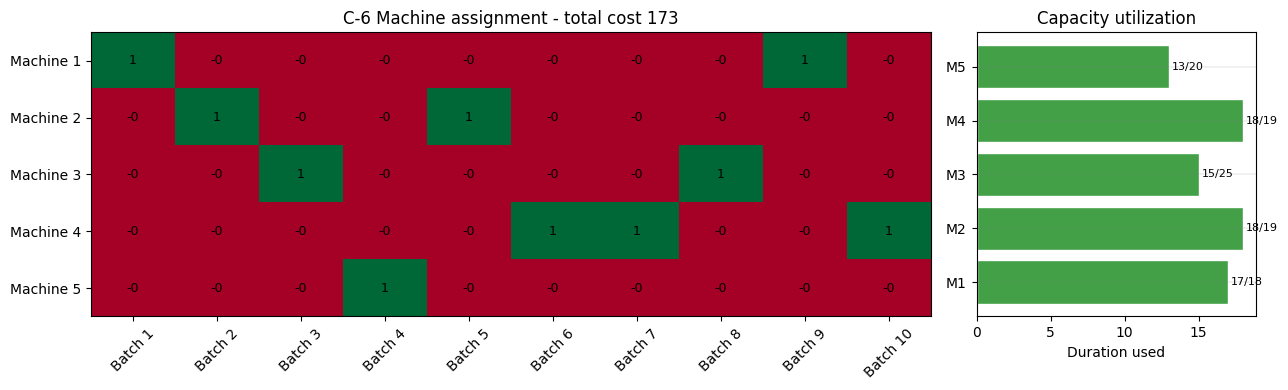

In [ ]:
cap_list = list(CAP_A.values())
dur_rows = [[DUR_A[(m,p)] for p in range(1,NB_A+1)] for m in range(1,NM_A+1)]

assign_matrix = np.array([[sol_use[(m,p)] for p in range(1,NB_A+1)] for m in range(1,NM_A+1)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4),
                                gridspec_kw={"width_ratios": [3, 1]})

im = ax1.imshow(assign_matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax1.set_xticks(range(NB_A)); ax1.set_xticklabels([f"Batch {p}" for p in range(1, NB_A+1)], rotation=45)
ax1.set_yticks(range(NM_A)); ax1.set_yticklabels([f"Machine {m}" for m in range(1, NM_A+1)])
ax1.set_title(f"C-6 Machine assignment - total cost {obj_val_c6:.0f}")
for m in range(NM_A):
    for p in range(NB_A):
        val = assign_matrix[m, p]
        ax1.text(p, m, f"{val:.0f}", ha="center", va="center",
                 fontsize=9, color="black")

# Capacity bar
dur_used = [sum(dur_rows[m-1][p-1] for p in range(1,NB_A+1) if sol_use[(m,p)] > 0.5)
            for m in range(1, NM_A+1)]
bar_colors = ["#43A047" if du <= cap else "#E53935" for du, cap in zip(dur_used, cap_list)]
ax2.barh(range(NM_A), dur_used, color=bar_colors, edgecolor="white")
for i, (du, cap) in enumerate(zip(dur_used, cap_list)):
    ax2.axhline(i, color="gray", linewidth=0.3, alpha=0.5)
    ax2.text(du + 0.2, i, f"{du}/{cap}", va="center", fontsize=8)
ax2.set_yticks(range(NM_A)); ax2.set_yticklabels([f"M{m}" for m in range(1, NM_A+1)])
ax2.set_xlabel("Duration used")
ax2.set_title("Capacity utilization")

plt.tight_layout(); plt.show()